In [9]:
from langgraph.graph import StateGraph, MessagesState, START, END

def mock_llm(state: MessagesState):
    return {"messages": [{"role": "ai", "content": "hello world"}]}


graph = StateGraph(MessagesState)

graph.add_node(mock_llm)
graph.add_edge(START, "mock_llm")
graph.add_edge("mock_llm", END)
graph = graph.compile()

graph.invoke({"messages": [{"role": "user", "content": "hi!"}]})


{'messages': [HumanMessage(content='hi!', additional_kwargs={}, response_metadata={}, id='984b0d51-7b22-486a-a94e-ea4630184c50'),
  AIMessage(content='hello world', additional_kwargs={}, response_metadata={}, id='e86817cf-faac-455c-8b17-bffe51cb39dc', tool_calls=[], invalid_tool_calls=[])]}

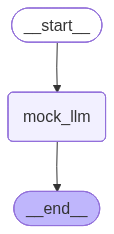

In [10]:
graph

In [11]:
from langgraph.func import entrypoint, task
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

def check_punchline(joke: str):
    """Gate function to check if the joke has a punchline"""
    # Simple check - does the joke contain "?" or "!"
    if "?" in joke or "!" in joke:
        return "Fail"

    return "Pass"

@task
def generate_joke(topic: str):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a short joke about {topic}")
    return msg.content  

@task
def improve_joke(joke: str):
    """Second LLM call to improve the joke"""
    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {joke}")
    return msg.content


@task
def polish_joke(joke: str):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {joke}")
    return msg.content                                        

In [18]:
@entrypoint()
def prompt_chaining_workflow(topic: str):
    original_joke = generate_joke(topic).result()
    if check_punchline(original_joke) == "Pass":
        return original_joke

    improved_joke = improve_joke(original_joke).result()
    return polish_joke(improved_joke).result()

In [21]:
for step in prompt_chaining_workflow.stream(
    {"topic": "cats"}, 
    stream_mode="updates"
):
    print(step)
    print("\n")

{'generate_joke': 'Why was the cat sitting on the computer?\n\nBecause it wanted to keep an eye on the mouse!'}


{'improve_joke': 'Why was the cat sitting on the computer?\n\nBecause it wanted to keep an eye on the mouse and make sure it didn’t click away!'}


{'polish_joke': 'Why was the cat sitting on the computer?\n\nBecause it wanted to keep an eye on the mouse, make sure it didn’t click away, and was secretly plotting to join a Zoom meeting to negotiate a raise in its treat allowance!'}


{'prompt_chaining_workflow': 'Why was the cat sitting on the computer?\n\nBecause it wanted to keep an eye on the mouse, make sure it didn’t click away, and was secretly plotting to join a Zoom meeting to negotiate a raise in its treat allowance!'}




In [22]:
@task
def call_llm_1(topic: str):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a joke about {topic}")
    return msg.content


@task
def call_llm_2(topic: str):
    """Second LLM call to generate story"""
    msg = llm.invoke(f"Write a story about {topic}")
    return msg.content


@task
def call_llm_3(topic):
    """Third LLM call to generate poem"""
    msg = llm.invoke(f"Write a poem about {topic}")
    return msg.content

In [23]:

@task
def aggregator(topic, joke, story, poem):
    """Combine the joke and story into a single output"""

    combined = f"Here's a story, joke, and poem about {topic}!\n\n"
    combined += f"STORY:\n{story}\n\n"
    combined += f"JOKE:\n{joke}\n\n"
    combined += f"POEM:\n{poem}"
    return combined

In [24]:
@entrypoint()
def parallel_workflow(topic: str):
    joke_fut = call_llm_1(topic)
    story_fut = call_llm_2(topic)
    poem_fut = call_llm_3(topic)
    return aggregator(
        topic, joke_fut.result(), story_fut.result(), poem_fut.result()
    ).result()

In [25]:
for step in parallel_workflow.stream(
    {"topic": "cats"}, 
    stream_mode="updates"
):
    print(step)
    print("\n")

{'call_llm_1': 'Why did the cat sit on the computer?\n\nBecause it wanted to keep an eye on the mouse!'}


{'call_llm_3': 'In a sunbeam’s glow where the silence sprawls,  \nA whiskered wanderer, the feline calls.  \nWith grace like a shadow, on padded feet,  \nA dance through the rooms, so gentle and sweet.  \n\nEyes like two lanterns, aglow in the night,  \nThey capture our secrets, reflecting the light.  \nWith a flick of her tail, she conquers the floor,  \nA monarch of comfort, forever adored.  \n\nPaws curl in slumber, so peaceful, so still,  \nIn dreams, she chases the world at her will.  \nA flick of her ear at the rustle of leaves,  \nIn her kingdom of pillows, she reigns with beliefs.  \n\nOde to the purrs that rumble like thunder,  \nThe soothing vibrations that pull us from slumber.  \nA soft little nudge, a head-butt surprise,  \nIn a world full of chaos, she opens our eyes.  \n\nHer antics delight with each playful leap,  \nA dashing explorer, never losing sleep.  \nFrom w

In [26]:
### router 
from typing_extensions import Literal
from pydantic import BaseModel, Field
from langchain.messages import HumanMessage, SystemMessage


class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )

In [27]:
router = llm.with_structured_output(Route)

In [28]:
router

RunnableBinding(bound=ChatOpenAI(profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x7eff45813c20>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7eff45add910>, root_client=<openai.OpenAI object at 0x7eff45813bf0>, root_async_client=<openai.AsyncOpenAI object at 0x7eff459dbe60>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=

In [30]:
@task
def llm_call_1(input_: str):
    """Write a story"""
    result = llm.invoke(input_)
    return result.content


@task
def llm_call_2(input_: str):
    """Write a joke"""
    result = llm.invoke(input_)
    return result.content


@task
def llm_call_3(input_: str):
    """Write a poem"""
    result = llm.invoke(input_)
    return result.content

def llm_call_router(input_: str):
    """Route the input to the appropriate node"""
    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=input_),
        ]
    )
    return decision.step

In [33]:
@entrypoint()
def router_workflow(input_: str):
    next_step = llm_call_router(input_)

    print("------------->", next_step)
    if next_step == "story":
        llm_call = llm_call_1
    elif next_step == "joke":
        llm_call = llm_call_2
    elif next_step == "poem":
        llm_call = llm_call_3

    return llm_call(input_).result()


In [34]:
for step in router_workflow.stream("Write me a joke about cats", stream_mode="updates"):
    print(step)
    print("\n")

-------------> joke
{'llm_call_2': 'Why was the cat sitting on the computer?\n\nBecause it wanted to keep an eye on the mouse!'}


{'router_workflow': 'Why was the cat sitting on the computer?\n\nBecause it wanted to keep an eye on the mouse!'}




In [35]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig
from typing import Annotated
from typing_extensions import TypedDict
from operator import add

class State(TypedDict):
    foo: str
    bar: Annotated[list[str], add]

def node_a(state: State):
    return {"foo": "a", "bar": ["a"]}

def node_b(state: State):
    return {"foo": "b", "bar": ["b"]}


workflow = StateGraph(State)
workflow.add_node(node_a)
workflow.add_node(node_b)
workflow.add_edge(START, "node_a")
workflow.add_edge("node_a", "node_b")
workflow.add_edge("node_b", END)

checkpointer = InMemorySaver()
graph = workflow.compile(checkpointer=checkpointer)

config: RunnableConfig = {"configurable": {"thread_id": "1"}}
graph.invoke({"foo": "", "bar":[]}, config)

{'foo': 'b', 'bar': ['a', 'b']}

In [36]:
config = {"configurable": {"thread_id": "1"}}
graph.get_state(config)

StateSnapshot(values={'foo': 'b', 'bar': ['a', 'b']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d26c-2f02-66b8-8002-45e328e93f02'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-21T02:06:51.376589+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d26c-2f00-6224-8001-b23e56047225'}}, tasks=(), interrupts=())

In [38]:
config = {"configurable": {"thread_id": "1", "checkpoint_id": "1f13d26c-2f02-66b8-8002-45e328e93f02"}}
graph.get_state(config)

StateSnapshot(values={'foo': 'b', 'bar': ['a', 'b']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f13d26c-2f02-66b8-8002-45e328e93f02'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-21T02:06:51.376589+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d26c-2f00-6224-8001-b23e56047225'}}, tasks=(), interrupts=())

In [39]:
config = {"configurable": {"thread_id": "1"}}
list(graph.get_state_history(config))

[StateSnapshot(values={'foo': 'b', 'bar': ['a', 'b']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d26c-2f02-66b8-8002-45e328e93f02'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-21T02:06:51.376589+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d26c-2f00-6224-8001-b23e56047225'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'foo': 'a', 'bar': ['a']}, next=('node_b',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d26c-2f00-6224-8001-b23e56047225'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-04-21T02:06:51.375649+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d26c-2efc-6dde-8000-f74ba2f870e6'}}, tasks=(PregelTask(id='7fedd07a-452b-9877-74d8-af4d83aaf19f', name='node_b', path=('__pregel_pull', 'node_b'), error=None, interrupts

In [41]:
history = list(graph.get_state_history(config))
history

[StateSnapshot(values={'foo': 'b', 'bar': ['a', 'b']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d26c-2f02-66b8-8002-45e328e93f02'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-21T02:06:51.376589+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d26c-2f00-6224-8001-b23e56047225'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'foo': 'a', 'bar': ['a']}, next=('node_b',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d26c-2f00-6224-8001-b23e56047225'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-04-21T02:06:51.375649+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d26c-2efc-6dde-8000-f74ba2f870e6'}}, tasks=(PregelTask(id='7fedd07a-452b-9877-74d8-af4d83aaf19f', name='node_b', path=('__pregel_pull', 'node_b'), error=None, interrupts

In [43]:
before_node_b = next(s for s in history if s.next == ("node_b",))
before_node_b

StateSnapshot(values={'foo': 'a', 'bar': ['a']}, next=('node_b',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d26c-2f00-6224-8001-b23e56047225'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-04-21T02:06:51.375649+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d26c-2efc-6dde-8000-f74ba2f870e6'}}, tasks=(PregelTask(id='7fedd07a-452b-9877-74d8-af4d83aaf19f', name='node_b', path=('__pregel_pull', 'node_b'), error=None, interrupts=(), state=None, result={'foo': 'b', 'bar': ['b']}),), interrupts=())

In [47]:
step_2 = next(s for s in history if s.metadata["step"] == 2)
forks = [s for s in history if s.metadata["source"] == "update"]
interrupted = next(
    s for s in history
    if s.tasks and any(t.interrupts for t in s.tasks)
)

StopIteration: 

In [51]:
from langgraph.store.memory import InMemoryStore
import uuid
store = InMemoryStore()

In [49]:
user_id = "1"
namespace_for_memory = (user_id, "memories")

In [52]:
memory_id = str(uuid.uuid4())
memory = {"food_preference" : "I like pizza"}
store.put(namespace_for_memory, memory_id, memory)

In [53]:
store

In [56]:
memories = store.search(namespace_for_memory)
memories
memories[-1].dict()

{'namespace': ['1', 'memories'],
 'key': '1f4b060f-6f04-4878-8aba-5614d24f0410',
 'value': {'food_preference': 'I like pizza'},
 'created_at': '2026-04-21T02:14:29.848438+00:00',
 'updated_at': '2026-04-21T02:14:29.848441+00:00',
 'score': None}

In [57]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class State(TypedDict):
  topic: str
  joke: str


def refine_topic(state: State):
    return {"topic": state["topic"] + " and cats"}


def generate_joke(state: State):
    return {"joke": f"This is a joke about {state['topic']}"}

graph = (
  StateGraph(State)
  .add_node(refine_topic)
  .add_node(generate_joke)
  .add_edge(START, "refine_topic")
  .add_edge("refine_topic", "generate_joke")
  .add_edge("generate_joke", END)
  .compile()
)

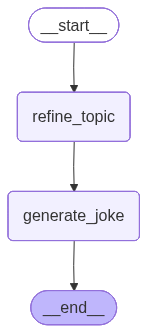

In [58]:
graph

In [59]:
for chunk in graph.stream(
    {"topic": "ice cream"},
    stream_mode="updates",
    version="v2",
):
    if chunk["type"] == "updates":
        for node_name, state in chunk["data"].items():
            print(f"Node `{node_name}` updated: {state}")

Node `refine_topic` updated: {'topic': 'ice cream and cats'}
Node `generate_joke` updated: {'joke': 'This is a joke about ice cream and cats'}


In [61]:
for chunk in graph.stream(
    {"topic": "ice cream"},
    stream_mode="values",
    version="v2",
):
   print(chunk)

{'type': 'values', 'ns': (), 'data': {'topic': 'ice cream'}, 'interrupts': ()}
{'type': 'values', 'ns': (), 'data': {'topic': 'ice cream and cats'}, 'interrupts': ()}
{'type': 'values', 'ns': (), 'data': {'topic': 'ice cream and cats', 'joke': 'This is a joke about ice cream and cats'}, 'interrupts': ()}


In [63]:
for chunk in graph.stream(
    {"topic": "ice cream"},
    stream_mode="messages",
    version="v2",
):
   print(chunk)